In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, accuracy_score, ConfusionMatrixDisplay
)
ANTIBIOTICS = ['IMIPENEM', 'CEFTAZIDIME', 'GENTAMICIN', 'AUGMENTIN', 'CIPROFLOXACIN']
LABEL_MAP   = {'S': 0, 'I': 1, 'R': 2}
INV_MAP     = {0: 'S', 1: 'I', 2: 'R'}
RANDOM_STATE = 40

## 2. Load & Inspect Data

In [2]:
df_raw = pd.read_excel('Dataset.xlsx')
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (274, 6)


,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,IFE-T,25,20,20,15,28
1,IFE-T,25,25,20,20,30
2,IFE-T,30,10,20,20,25
3,IFE-T,25,20,20,25,28
4,IFE-T,25,7,20,20,22


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Location       274 non-null    object
 1   IMIPENEM       274 non-null    int64 
 2   CEFTAZIDIME    274 non-null    int64 
 3   GENTAMICIN     274 non-null    int64 
 4   AUGMENTIN      274 non-null    int64 
 5   CIPROFLOXACIN  274 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 13.0+ KB


In [4]:
print("Missing values:")
print(df_raw.isnull().sum())
print("\nZero values:")
print((df_raw == 0).sum())

Missing values:
Location         0
IMIPENEM         0
CEFTAZIDIME      0
GENTAMICIN       0
AUGMENTIN        0
CIPROFLOXACIN    0
dtype: int64

Zero values:
Location           0
IMIPENEM           1
CEFTAZIDIME      123
GENTAMICIN        12
AUGMENTIN         69
CIPROFLOXACIN     27
dtype: int64


In [6]:
# ummary of zone diameters (before classification)
df_raw.select_dtypes(include='number').describe()

,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
count,274.000000,274.000000,274.000000,274.000000,274.000000
mean,24.430657,8.605839,16.806569,11.237226,19.138686
std,5.788451,8.996017,5.553848,8.141060,7.936269
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,15.000000,1.000000,17.000000
50%,24.000000,8.500000,18.000000,12.000000,21.000000
75%,28.000000,15.000000,20.000000,17.000000,25.000000
max,40.000000,32.000000,30.000000,35.000000,35.000000


## 3. Preprocessing

In [7]:
df = df_raw.copy()

# Split 'Location-Area' into two columns
df[['Location', 'Area']] = df['Location'].str.split('-', expand=True)
df['Location'] = df['Location'].str.strip()
df['Area']     = df['Area'].str.strip()

print("Locations:", df['Location'].unique())
print("Areas:    ", df['Area'].unique())
df.head()

Locations: ['IFE' 'OSU' 'IWO' 'EDE']
Areas:     ['T' 'C' 'S']


,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area
0,IFE,25,20,20,15,28,T
1,IFE,25,25,20,20,30,T
2,IFE,30,10,20,20,25,T
3,IFE,25,20,20,25,28,T
4,IFE,25,7,20,20,22,T


In [8]:

# S = Susceptible, I = Intermediate, R = Resistant
BREAKPOINTS = {
    'CIPROFLOXACIN': {'S': 21, 'I': 16},   
    'IMIPENEM':      {'S': 23, 'I': 20},
    'CEFTAZIDIME':   {'S': 18, 'I': 15},
    'GENTAMICIN':    {'S': 15, 'I': 13},
    'AUGMENTIN':     {'S': 18, 'I': 14},
}

def classify_zone(value, drug):
    bp = BREAKPOINTS[drug]
    if value >= bp['S']: return 'S'
    elif value >= bp['I']: return 'I'
    else: return 'R'

for drug in ANTIBIOTICS:
    df[drug] = df[drug].apply(lambda x: classify_zone(x, drug))

print("Classification complete.")
df[ANTIBIOTICS].head()

Classification complete.


,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,S,S,S,I,S
1,S,S,S,S,S
2,S,R,S,S,S
3,S,S,S,S,S
4,S,R,S,S,S


In [9]:
# Encode S/I/R → 0/1/2
df_enc = df.copy()
df_enc[ANTIBIOTICS] = df_enc[ANTIBIOTICS].replace(LABEL_MAP)

# MDR: resistant (R=2) to 3 or more antibiotics
df_enc['resistance_count'] = (df_enc[ANTIBIOTICS] == 2).sum(axis=1)
df_enc['MDR']              = (df_enc['resistance_count'] >= 3).astype(int)

print(f"MDR rate: {df_enc['MDR'].mean():.1%}")
df_enc.head()

MDR rate: 25.2%


,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Area,resistance_count,MDR
0,IFE,0,0,0,1,0,T,0,0
1,IFE,0,0,0,0,0,T,0,0
2,IFE,0,2,0,0,0,T,1,0
3,IFE,0,0,0,0,0,T,0,0
4,IFE,0,2,0,0,0,T,1,0


## 4. Exploratory Data Analysis

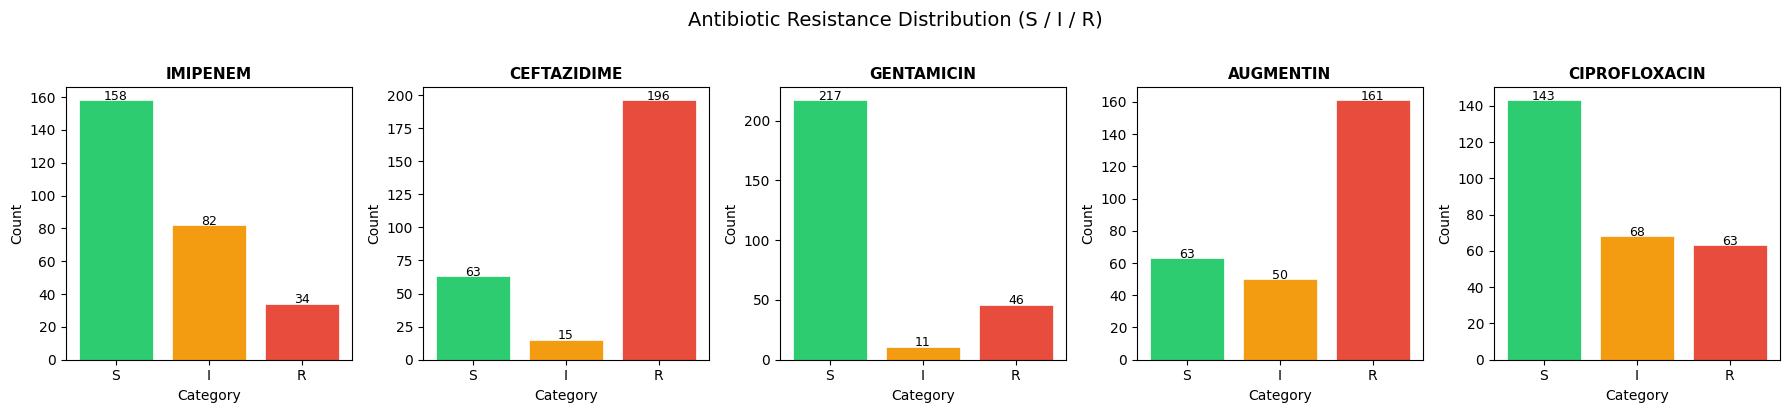

In [10]:
# ── S/I/R distribution per antibiotic ─────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

colors = {'S': '#2ecc71', 'I': '#f39c12', 'R': '#e74c3c'}

for ax, drug in zip(axes, ANTIBIOTICS):
    counts = df[drug].value_counts().reindex(['S', 'I', 'R'])
    bars = ax.bar(['S', 'I', 'R'], counts,
                  color=[colors['S'], colors['I'], colors['R']],
                  edgecolor='white', linewidth=0.5)
    ax.set_title(drug, fontsize=11, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(val)), ha='center', fontsize=9)

plt.suptitle('Antibiotic Resistance Distribution (S / I / R)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

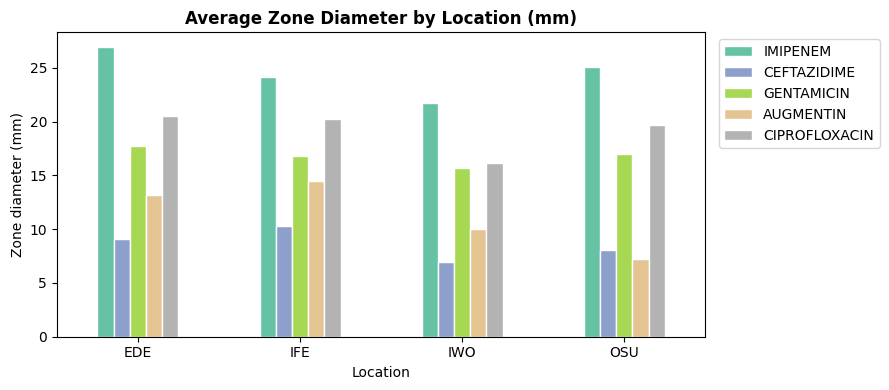

In [12]:
# ── Average zone diameter by Location ─────────────────────────────────────
# Use raw numeric data (before classification)
df_raw2 = df_raw.copy()
df_raw2[['Location', 'Area']] = df_raw2['Location'].str.split('-', expand=True)

ax = df_raw2.groupby('Location')[ANTIBIOTICS].mean().plot(kind='bar', figsize=(9, 4),
    colormap='Set2', edgecolor='white')
plt.title('Average Zone Diameter by Location (mm)', fontweight='bold')
plt.ylabel('Zone diameter (mm)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

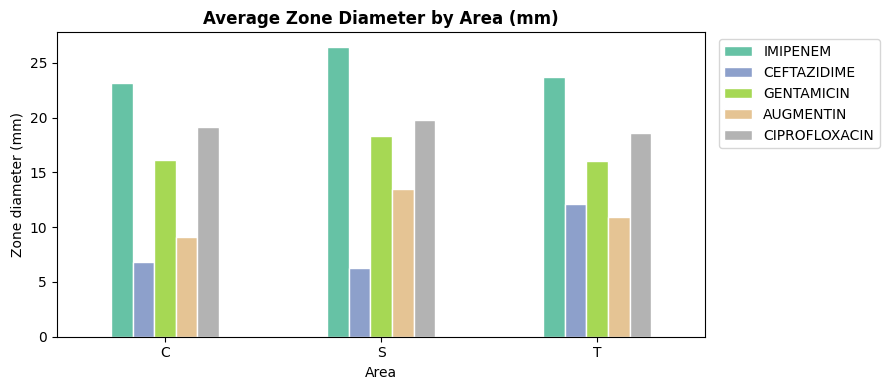

In [13]:
# ── Average zone diameter by Area ─────────────────────────────────────────
df_raw2.groupby('Area')[ANTIBIOTICS].mean().plot(kind='bar', figsize=(9, 4),
    colormap='Set2', edgecolor='white')
plt.title('Average Zone Diameter by Area (mm)', fontweight='bold')
plt.ylabel('Zone diameter (mm)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

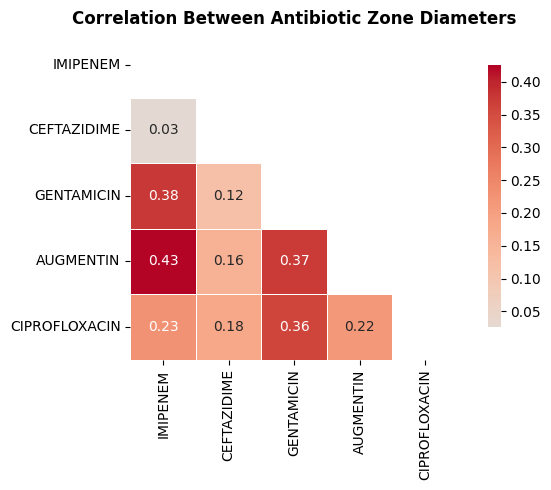


Note: Weak correlations suggest independent resistance mechanisms across antibiotics.


In [14]:
# ── Correlation heatmap (zone diameters) ──────────────────────────────────
corr = df_raw2[ANTIBIOTICS].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Antibiotic Zone Diameters', fontweight='bold')
plt.tight_layout()
plt.show()
print("\nNote: Weak correlations suggest independent resistance mechanisms across antibiotics.")

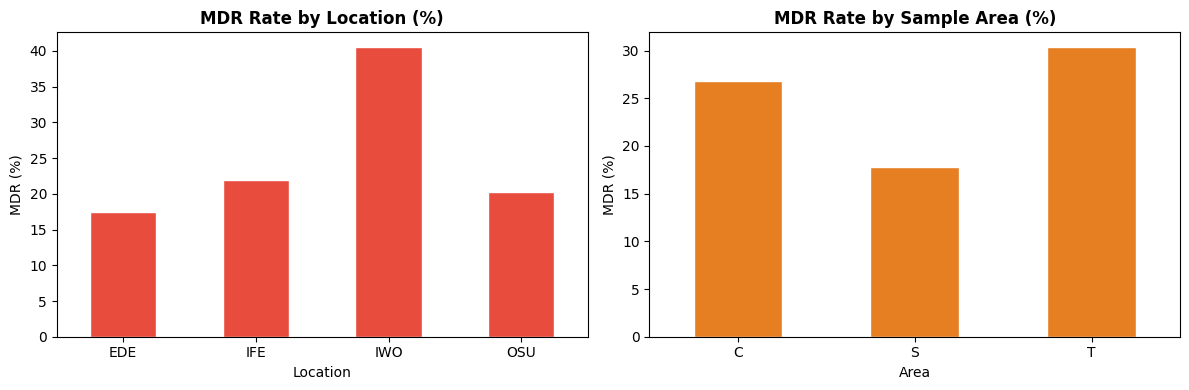

In [15]:
# ── MDR rate by Location & Area ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_enc.groupby('Location')['MDR'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('MDR Rate by Location (%)', fontweight='bold')
axes[0].set_ylabel('MDR (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df_enc.groupby('Area')['MDR'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('MDR Rate by Sample Area (%)', fontweight='bold')
axes[1].set_ylabel('MDR (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

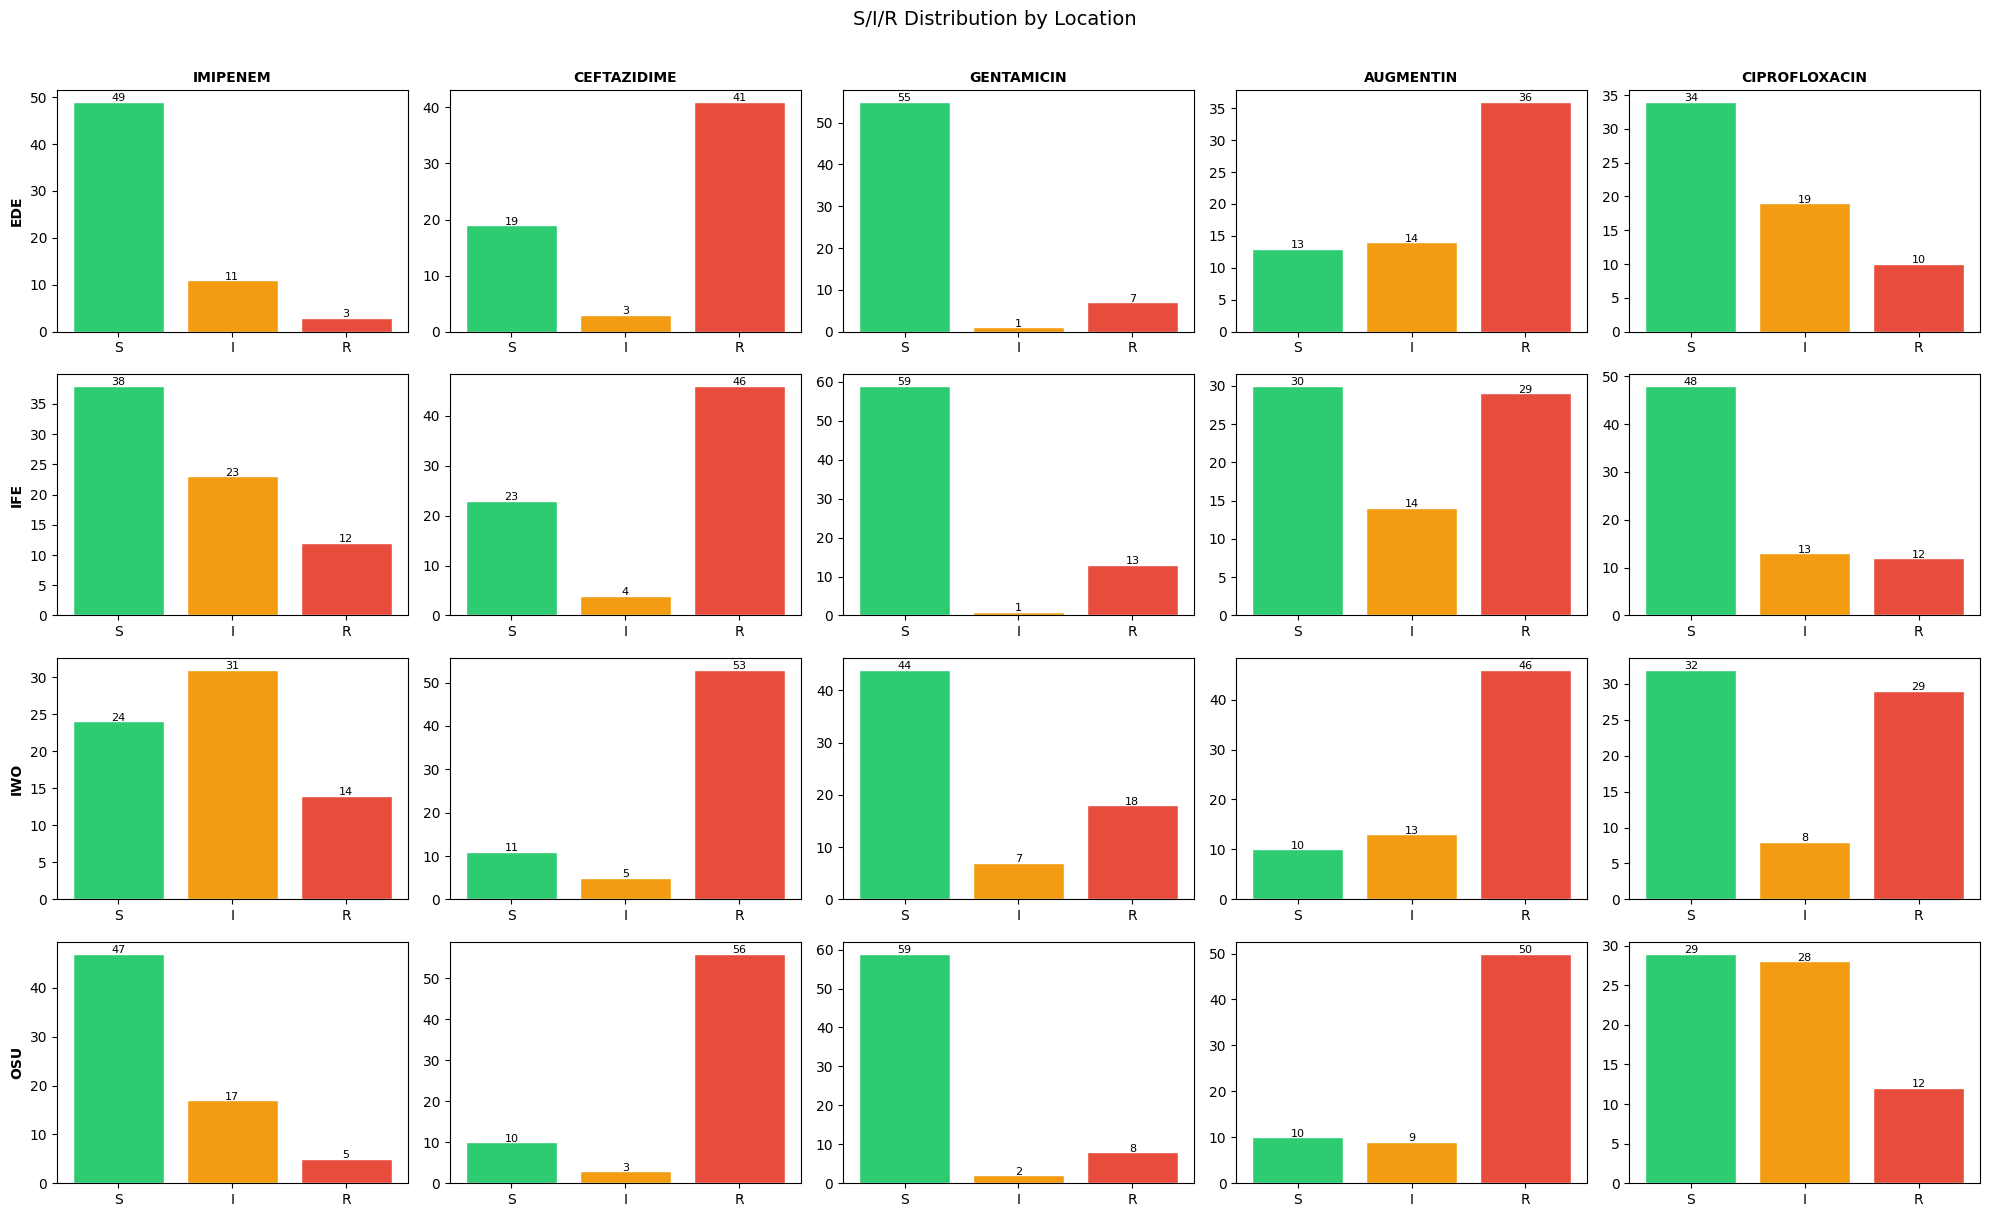

In [16]:
# ── S/I/R breakdown by Location × Antibiotic ─────────────────────────────
locations = df['Location'].unique()
fig, axes = plt.subplots(len(locations), len(ANTIBIOTICS), figsize=(20, 12), sharey=False)

for i, loc in enumerate(sorted(locations)):
    df_loc = df[df['Location'] == loc]
    for j, drug in enumerate(ANTIBIOTICS):
        counts = df_loc[drug].value_counts().reindex(['S', 'I', 'R']).fillna(0)
        ax = axes[i, j]
        ax.bar(['S', 'I', 'R'], counts,
               color=[colors['S'], colors['I'], colors['R']],
               edgecolor='white')
        if i == 0: ax.set_title(drug, fontsize=10, fontweight='bold')
        if j == 0: ax.set_ylabel(loc, fontsize=10, fontweight='bold')
        for k, val in enumerate(counts):
            ax.text(k, val + 0.1, str(int(val)), ha='center', fontsize=8)

plt.suptitle('S/I/R Distribution by Location', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Train/Test Split

In [17]:
# ── Build feature matrix ───────────────────────────────────────────────────
# Features: Location, Area, sample density per group, resistance_count
# Note: resistance_count counts total resistant drugs per isolate and is
# a valid input feature (it does NOT leak individual drug labels since
# we are predicting each drug's S/I/R outcome, not resistance_count itself).

feature_df = df_enc[['Location', 'Area', 'resistance_count']].copy()

# Group size as a proxy for sample density (how many isolates from this site)
feature_df['group_size'] = feature_df.groupby(['Location', 'Area'])['resistance_count'].transform('count')

# One-hot encode categorical features
X = pd.get_dummies(feature_df, columns=['Location', 'Area'])
y = df_enc[ANTIBIOTICS].astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Label matrix:   {y.shape}")
print(f"Features: {list(X.columns)}")
X.head()

Feature matrix: (274, 9)
Label matrix:   (274, 5)
Features: ['resistance_count', 'group_size', 'Location_EDE', 'Location_IFE', 'Location_IWO', 'Location_OSU', 'Area_C', 'Area_S', 'Area_T']


,resistance_count,group_size,Location_EDE,Location_IFE,Location_IWO,Location_OSU,Area_C,Area_S,Area_T
0,0,31,False,True,False,False,False,False,True
1,0,31,False,True,False,False,False,False,True
2,1,31,False,True,False,False,False,False,True
3,0,31,False,True,False,False,False,False,True
4,1,31,False,True,False,False,False,False,True


In [18]:
# ── Single train/test split (80/20) ───────────────────────────────────────
# All models and evaluations use THIS split — no re-splitting later.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ── Compute susceptibility frequencies from TRAIN SET ONLY ────────────────
# Using only training data avoids data leakage in the recommendation engine.
train_meta = df_enc.loc[X_train.index][['Location', 'Area']]
train_full  = pd.concat([train_meta.reset_index(drop=True),
                          y_train.reset_index(drop=True)], axis=1)

freq_S = train_full.groupby(['Location','Area'])[ANTIBIOTICS].apply(
    lambda x: (x == 0).mean(), include_groups=False)
freq_I = train_full.groupby(['Location','Area'])[ANTIBIOTICS].apply(
    lambda x: (x == 1).mean(), include_groups=False)

print("\nSusceptibility frequency table (train only):")
freq_S

Train: 219 samples | Test: 55 samples

Susceptibility frequency table (train only):


IMIPENEM  CEFTAZIDIME  GENTAMICIN  AUGMENTIN  CIPROFLOXACIN
Location Area                                                             
EDE      C     0.769231     0.384615    0.769231   0.076923       0.538462
         S     0.687500     0.250000    0.937500   0.000000       0.625000
         T     0.823529     0.235294    0.941176   0.411765       0.470588
IFE      C     0.285714     0.071429    0.714286   0.285714       0.714286
         S     0.705882     0.294118    0.941176   0.411765       0.588235
         T     0.521739     0.478261    0.826087   0.434783       0.695652
IWO      C     0.352941     0.058824    0.647059   0.235294       0.529412
         S     0.500000     0.050000    0.800000   0.050000       0.450000
         T     0.285714     0.238095    0.428571   0.095238       0.476190
OSU      C     0.550000     0.050000    0.800000   0.100000       0.350000
         S     0.947368     0.210526    1.000000   0.315789       0.526316
         T     0.500000     0.227273    0.727273   0.000000       0.409091

## 6. Cross-Validation (per antibiotic)

5-fold Cross-Validation (RandomForest baseline)

  IMIPENEM       : 0.494 ± 0.031
  CEFTAZIDIME    : 0.492 ± 0.050
  GENTAMICIN     : 0.478 ± 0.090
  AUGMENTIN      : 0.556 ± 0.015
  CIPROFLOXACIN  : 0.544 ± 0.047


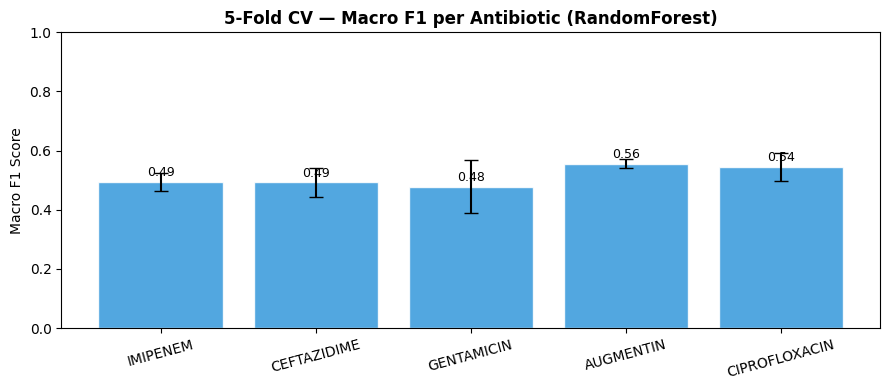

In [19]:
# ── 5-fold CV with RandomForest as baseline ───────────────────────────────
# Multi-output StratifiedKFold isn't directly supported, so we evaluate
# each antibiotic independently to get reliable per-drug estimates.

cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=RANDOM_STATE)

print("5-fold Cross-Validation (RandomForest baseline)\n")
for drug in ANTIBIOTICS:
    scores = cross_val_score(rf_base, X, y[drug], cv=cv, scoring='f1_macro')
    cv_results[drug] = scores
    print(f"  {drug:15s}: {scores.mean():.3f} ± {scores.std():.3f}")

# Plot CV scores
fig, ax = plt.subplots(figsize=(9, 4))
positions = range(len(ANTIBIOTICS))
means  = [cv_results[d].mean() for d in ANTIBIOTICS]
stds   = [cv_results[d].std()  for d in ANTIBIOTICS]

bars = ax.bar(positions, means, yerr=stds, capsize=5,
              color='#3498db', edgecolor='white', alpha=0.85)
ax.set_xticks(positions)
ax.set_xticklabels(ANTIBIOTICS, rotation=15)
ax.set_ylabel('Macro F1 Score')
ax.set_title('5-Fold CV — Macro F1 per Antibiotic (RandomForest)', fontweight='bold')
ax.set_ylim(0, 1)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{m:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Multi-Model Comparison

In [21]:
# ── Optional model availability flags ────────────────────────────────────
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from catboost import CatBoostClassifier
    HAS_CB = True
except ImportError:
    HAS_CB = False


# ── Define all models ─────────────────────────────────────────────────────
MODELS = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

if HAS_XGB:
    MODELS['XGBoost'] = XGBClassifier(
        objective='multi:softmax', num_class=3,
        n_estimators=100, learning_rate=0.1, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0)

if HAS_LGBM:
    MODELS['LightGBM'] = LGBMClassifier(
        n_estimators=100, learning_rate=0.1, num_class=3,
        random_state=RANDOM_STATE, verbosity=-1)

if HAS_CB:
    MODELS['CatBoost'] = CatBoostClassifier(
        iterations=100, depth=4, learning_rate=0.1,
        random_state=RANDOM_STATE, verbose=0)

print(f"Models to evaluate: {list(MODELS.keys())}")

Models to evaluate: ['RandomForest', 'GradientBoosting', 'DecisionTree', 'AdaBoost', 'KNN', 'XGBoost', 'LightGBM', 'CatBoost']


In [22]:
# ── Train all models and collect per-antibiotic metrics ───────────────────
trained_preds = {}   # model_name -> y_pred array
summary_rows  = []

for name, clf in MODELS.items():
    print(f"  Training {name}...", end=' ')
    multi = MultiOutputClassifier(clf)
    multi.fit(X_train, y_train)

    y_pred = multi.predict(X_test)
    if len(y_pred.shape) == 3:
        y_pred = np.squeeze(y_pred)
    y_pred = np.array(y_pred)

    trained_preds[name] = y_pred

    for i, drug in enumerate(ANTIBIOTICS):
        summary_rows.append({
            'Model':     name,
            'Antibiotic': drug,
            'Accuracy':  accuracy_score(y_test[drug], y_pred[:, i]),
            'F1':        f1_score(y_test[drug], y_pred[:, i], average='macro', zero_division=0),
            'Precision': precision_score(y_test[drug], y_pred[:, i], average='macro', zero_division=0),
            'Recall':    recall_score(y_test[drug], y_pred[:, i], average='macro', zero_division=0),
        })
    print("done")

summary_df = pd.DataFrame(summary_rows)
print("\nAll models trained.")

  Training RandomForest... done
  Training GradientBoosting... done
  Training DecisionTree... done
  Training AdaBoost... done
  Training KNN... done
  Training XGBoost... done
  Training LightGBM... done
  Training CatBoost... done

All models trained.


In [23]:
# ── Overall model ranking ─────────────────────────────────────────────────
overall = (
    summary_df
    .groupby('Model')[['Accuracy', 'F1', 'Precision', 'Recall']]
    .mean()
    .round(3)
    .sort_values('F1', ascending=False)
)
print("Model Ranking (mean across all 5 antibiotics):")
overall

Model Ranking (mean across all 5 antibiotics):


,Accuracy,F1,Precision,Recall
Model,,,,
CatBoost,0.785,0.605,0.647,0.605
LightGBM,0.771,0.593,0.623,0.595
XGBoost,0.753,0.589,0.610,0.586
GradientBoosting,0.756,0.586,0.608,0.587
RandomForest,0.691,0.573,0.601,0.567
AdaBoost,0.760,0.562,0.561,0.580
DecisionTree,0.644,0.543,0.563,0.540
KNN,0.705,0.514,0.597,0.502


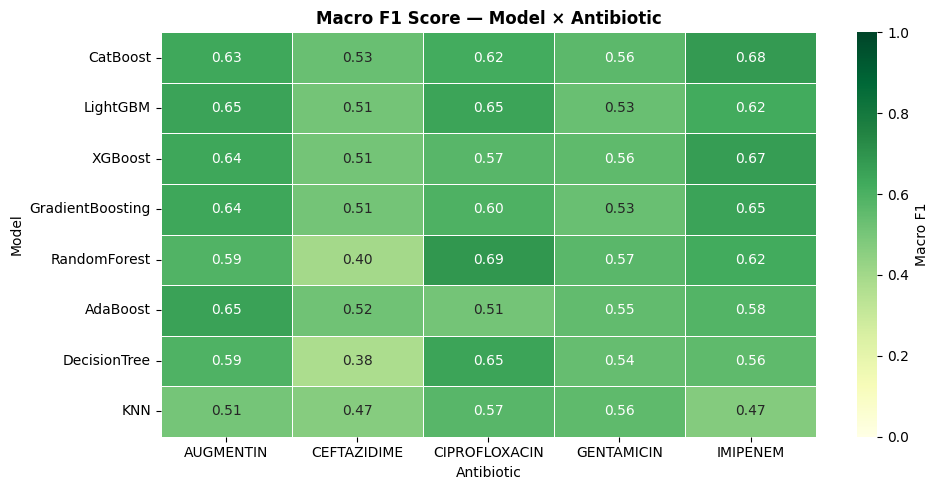

In [24]:
# ── F1 heatmap: Model × Antibiotic ────────────────────────────────────────
pivot_f1 = summary_df.pivot(index='Model', columns='Antibiotic', values='F1')
pivot_f1 = pivot_f1.loc[overall.index]   # sort by mean F1

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_f1, annot=True, fmt='.2f', cmap='YlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Macro F1'})
ax.set_title('Macro F1 Score — Model × Antibiotic', fontweight='bold')
ax.set_ylabel('Model')
ax.set_xlabel('Antibiotic')
plt.tight_layout()
plt.show()

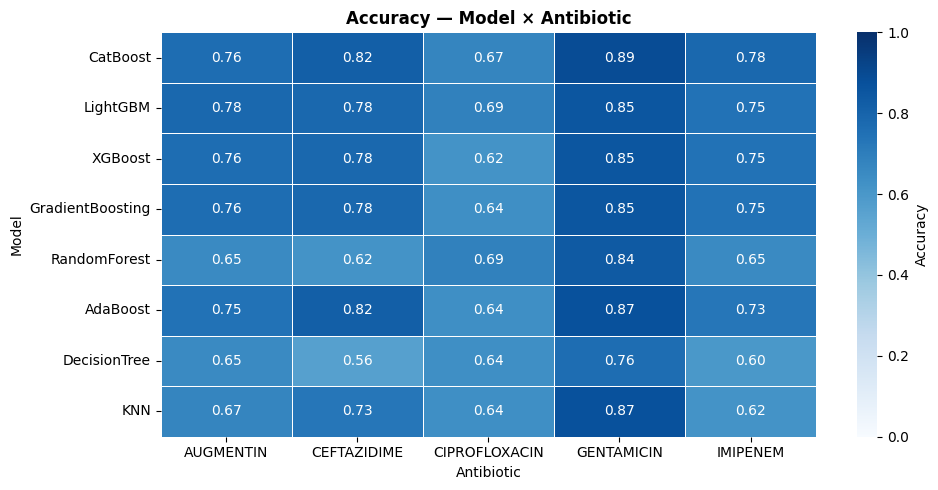

In [25]:
# ── Accuracy heatmap: Model × Antibiotic ──────────────────────────────────
pivot_acc = summary_df.pivot(index='Model', columns='Antibiotic', values='Accuracy')
pivot_acc = pivot_acc.loc[overall.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_acc, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Accuracy'})
ax.set_title('Accuracy — Model × Antibiotic', fontweight='bold')
ax.set_ylabel('Model')
ax.set_xlabel('Antibiotic')
plt.tight_layout()
plt.show()

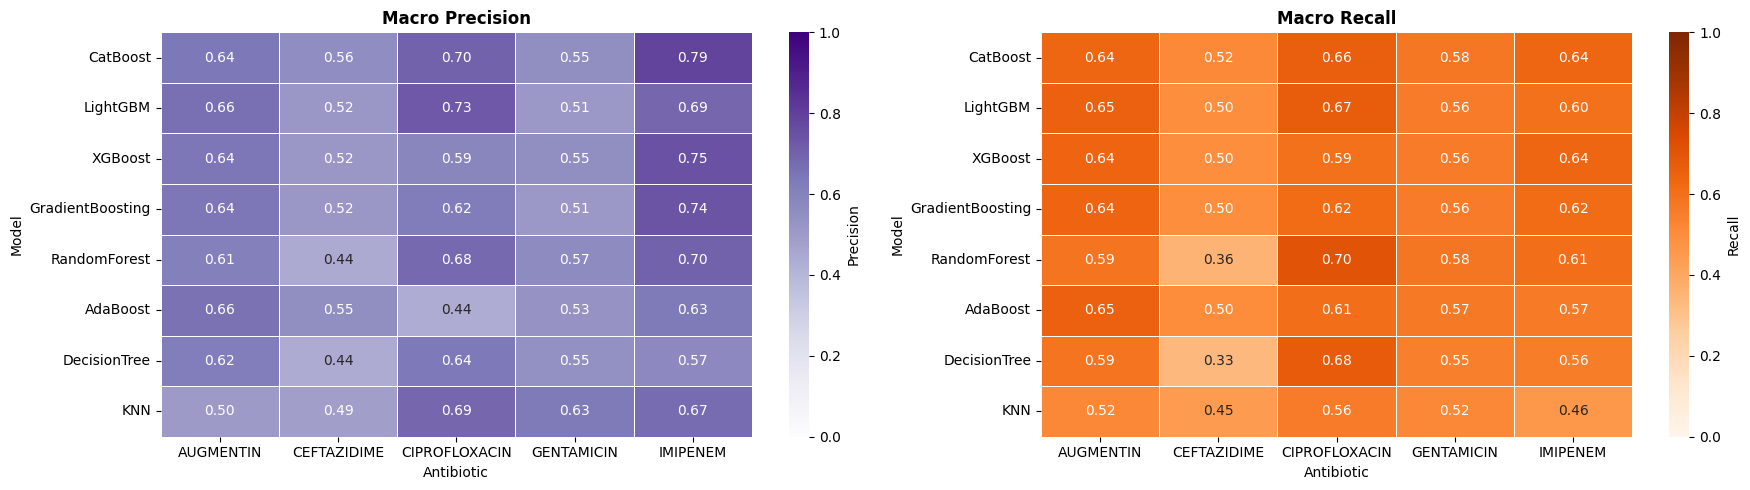

In [26]:
# ── Precision & Recall heatmaps side by side ──────────────────────────────
pivot_prec = summary_df.pivot(index='Model', columns='Antibiotic', values='Precision').loc[overall.index]
pivot_rec  = summary_df.pivot(index='Model', columns='Antibiotic', values='Recall').loc[overall.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_prec, annot=True, fmt='.2f', cmap='Purples',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Precision'})
axes[0].set_title('Macro Precision', fontweight='bold')

sns.heatmap(pivot_rec, annot=True, fmt='.2f', cmap='Oranges',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Recall'})
axes[1].set_title('Macro Recall', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Best Model — Detailed Evaluation

In [27]:
# ── Pick best model by mean F1 ────────────────────────────────────────────
best_name = overall['F1'].idxmax()
best_pred = trained_preds[best_name]
print(f"Best model: {best_name}  (mean F1 = {overall.loc[best_name, 'F1']:.3f})")

Best model: CatBoost  (mean F1 = 0.605)


In [28]:
# ── Classification report for best model ──────────────────────────────────
for i, drug in enumerate(ANTIBIOTICS):
    print(f"\n{'='*40}")
    print(f" {drug}")
    print(f"{'='*40}")
    print(classification_report(
        y_test[drug], best_pred[:, i],
        target_names=['S (0)', 'I (1)', 'R (2)'],
        zero_division=0
    ))


 IMIPENEM
              precision    recall  f1-score   support

       S (0)       0.79      1.00      0.88        33
       I (1)       0.57      0.36      0.44        11
       R (2)       1.00      0.55      0.71        11

    accuracy                           0.78        55
   macro avg       0.79      0.64      0.68        55
weighted avg       0.79      0.78      0.76        55


 CEFTAZIDIME
              precision    recall  f1-score   support

       S (0)       0.77      0.62      0.69        16
       I (1)       0.00      0.00      0.00         1
       R (2)       0.90      0.92      0.91        38

    accuracy                           0.82        55
   macro avg       0.56      0.52      0.53        55
weighted avg       0.84      0.82      0.83        55


 GENTAMICIN
              precision    recall  f1-score   support

       S (0)       0.93      0.93      0.93        44
       I (1)       0.00      0.00      0.00         1
       R (2)       0.73      0.80    

In [44]:
# Convert y_test to S/I/R and attach Location & Area metadata
ytest_df = y_test.copy().replace(INV_MAP)
test_meta = df_enc.loc[X_test.index][['Location', 'Area']].reset_index(drop=True)
ytest_df  = pd.concat([test_meta, ytest_df.reset_index(drop=True)], axis=1)

print("y_test table:")
ytest_df.head(10)

y_test table:


,Location,Area,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,IFE,S,S,S,S,S,S
1,IFE,T,S,S,I,S,S
2,EDE,T,S,S,S,S,S
3,OSU,C,I,R,S,R,I
4,IWO,C,R,S,S,R,R
5,IWO,T,S,S,S,S,S
6,OSU,S,S,R,S,R,I
7,IFE,C,I,R,S,S,S
8,OSU,C,S,R,S,R,S
9,IFE,C,R,R,S,R,R


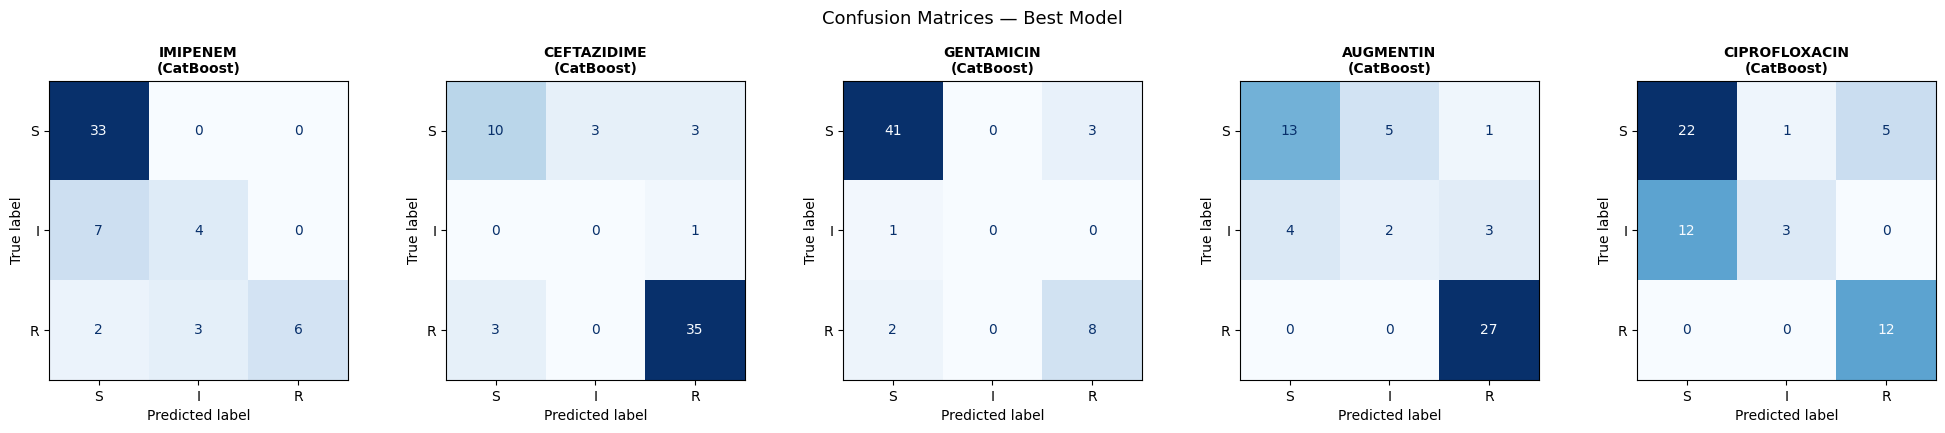

In [29]:
# ── Confusion matrices for best model ─────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (drug, ax) in enumerate(zip(ANTIBIOTICS, axes)):
    ConfusionMatrixDisplay.from_predictions(
        y_test[drug], best_pred[:, i],
        display_labels=['S', 'I', 'R'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"{drug}\n({best_name})", fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — Best Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance

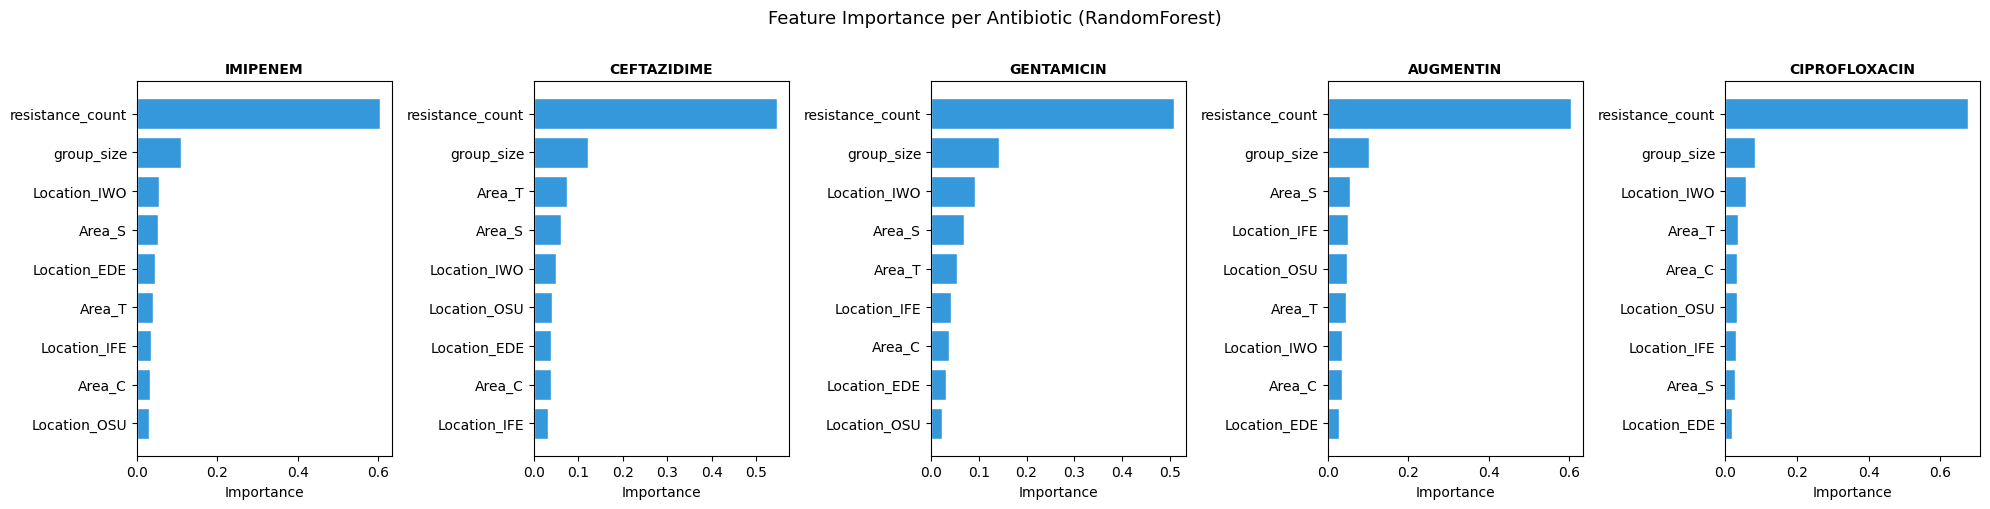

In [30]:
# ── Feature importance for all 5 antibiotics (RandomForest) ──────────────
# Train a dedicated RF for clean feature importance plots
rf_fi = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           random_state=RANDOM_STATE)
)
rf_fi.fit(X_train, y_train)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (drug, ax) in enumerate(zip(ANTIBIOTICS, axes)):
    imp = rf_fi.estimators_[i].feature_importances_
    sorted_idx = np.argsort(imp)[::-1]
    ax.barh(
        [X_train.columns[j] for j in sorted_idx],
        imp[sorted_idx],
        color='#3498db', edgecolor='white'
    )
    ax.set_title(drug, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.suptitle('Feature Importance per Antibiotic (RandomForest)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

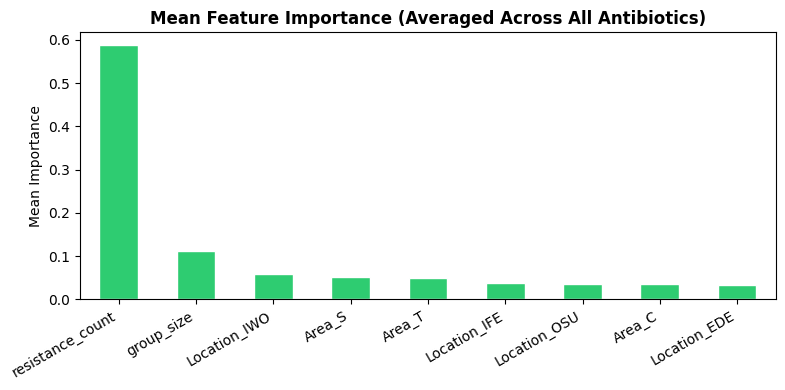

In [31]:
# ── Mean feature importance across all antibiotics ─────────────────────────
mean_imp = np.mean(
    [est.feature_importances_ for est in rf_fi.estimators_], axis=0
)
imp_series = pd.Series(mean_imp, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
imp_series.plot(kind='bar', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Mean Feature Importance (Averaged Across All Antibiotics)', fontweight='bold')
ax.set_ylabel('Mean Importance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Antibiotic Recommendation Engine

In [32]:
# ── Build prediction table ─────────────────────────────────────────────────
# Use the best model's predictions on the test set
pred_df = pd.DataFrame(best_pred, columns=ANTIBIOTICS).replace(INV_MAP)

# Attach Location & Area from original data (no leakage — test set meta only)
test_meta = df_enc.loc[X_test.index][['Location', 'Area']].reset_index(drop=True)
pred_df   = pd.concat([test_meta, pred_df], axis=1)

pred_df.head(10)

,Location,Area,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,IFE,S,S,S,S,S,S
1,IFE,T,S,S,S,S,S
2,EDE,T,S,I,S,S,S
3,OSU,C,S,R,S,R,I
4,IWO,C,I,R,R,R,R
5,IWO,T,S,S,S,I,S
6,OSU,S,S,R,S,R,I
7,IFE,C,S,R,S,S,S
8,OSU,C,S,R,S,R,I
9,IFE,C,R,R,R,R,R


In [42]:
def recommend_antibiotic(row):
    """
    Recommend antibiotics ranked by historical susceptibility rate
    at the same Location & Area (from training data).
    - Lists ALL Susceptible (S) drugs, ranked best → worst
    - If no S, lists ALL Intermediate (I) drugs, ranked best → worst
    - If neither, reports pan-resistance
    """
    loc, area = row['Location'], row['Area']

    def get_freq(freq_table, drug):
        try:
            return freq_table.loc[(loc, area), drug]
        except KeyError:
            return 0.0

    s_drugs = [d for d in ANTIBIOTICS if row[d] == 'S']
    if s_drugs:
        ranked = sorted(s_drugs, key=lambda d: get_freq(freq_S, d), reverse=True)
        return ' > '.join(ranked)

    i_drugs = [d for d in ANTIBIOTICS if row[d] == 'I']
    if i_drugs:
        ranked = sorted(i_drugs, key=lambda d: get_freq(freq_I, d), reverse=True)
        return '[I only] ' + ' > '.join(ranked)

    return 'No effective antibiotic'


pred_df['Recommended'] = pred_df.apply(recommend_antibiotic, axis=1)
print("Recommendation complete.")
pred_df.head(10)

Recommendation complete.


,Location,Area,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN,Recommended
0,IFE,S,S,S,S,S,S,GENTAMICIN > IMIPENEM > CIPROFLOXACIN > AUGMEN...
1,IFE,T,S,S,S,S,S,GENTAMICIN > CIPROFLOXACIN > IMIPENEM > CEFTAZ...
2,EDE,T,S,I,S,S,S,GENTAMICIN > IMIPENEM > CIPROFLOXACIN > AUGMENTIN
3,OSU,C,S,R,S,R,I,GENTAMICIN > IMIPENEM
4,IWO,C,I,R,R,R,R,[I only] IMIPENEM
5,IWO,T,S,S,S,I,S,CIPROFLOXACIN > GENTAMICIN > IMIPENEM > CEFTAZ...
6,OSU,S,S,R,S,R,I,GENTAMICIN > IMIPENEM
7,IFE,C,S,R,S,S,S,GENTAMICIN > CIPROFLOXACIN > IMIPENEM > AUGMENTIN
8,OSU,C,S,R,S,R,I,GENTAMICIN > IMIPENEM
9,IFE,C,R,R,R,R,R,No effective antibiotic


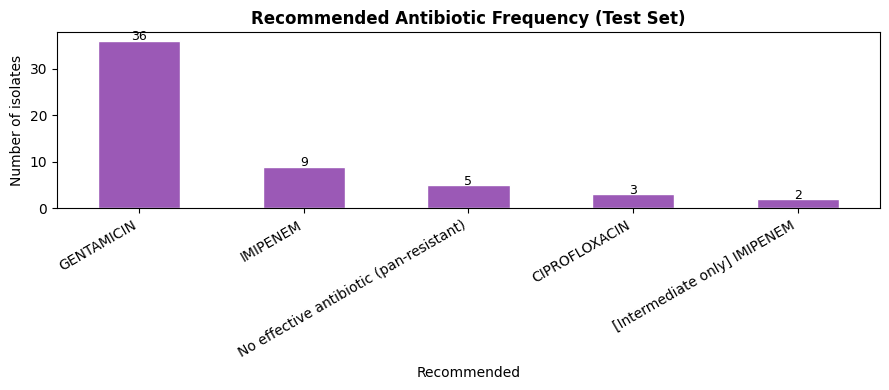

In [34]:
# ── Recommendation frequency summary ──────────────────────────────────────
rec_counts = pred_df['Recommended'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
rec_counts.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Recommended Antibiotic Frequency (Test Set)', fontweight='bold')
ax.set_ylabel('Number of isolates')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.1,
            str(int(p.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
# ── Save prediction output ─────────────────────────────────────────────────
pred_df.to_csv('nigeria_predictions.csv', index=False)
print("Saved to nigeria_predictions.csv")

Saved to nigeria_predictions.csv


## 11. Summary & Insights

In [36]:
print("="*55)
print(" SUMMARY")
print("="*55)
print(f"\nDataset size : {len(df_enc)} isolates")
print(f"MDR rate     : {df_enc['MDR'].mean():.1%}")
print(f"\nBest model   : {best_name}")
print(f"Mean F1      : {overall.loc[best_name, 'F1']:.3f}")
print(f"Mean Accuracy: {overall.loc[best_name, 'Accuracy']:.3f}")
print()

print("Per-antibiotic F1 (best model):")
for i, drug in enumerate(ANTIBIOTICS):
    f1 = f1_score(y_test[drug], best_pred[:, i], average='macro', zero_division=0)
    print(f"  {drug:15s}: {f1:.3f}")

print()
print("Most common recommendation:", rec_counts.idxmax())
print("Pan-resistant isolates     :",
      (pred_df['Recommended'] == 'No effective antibiotic (pan-resistant)').sum())
print("="*55)

 SUMMARY

Dataset size : 274 isolates
MDR rate     : 25.2%

Best model   : CatBoost
Mean F1      : 0.605
Mean Accuracy: 0.785

Per-antibiotic F1 (best model):
  IMIPENEM       : 0.677
  CEFTAZIDIME    : 0.533
  GENTAMICIN     : 0.565
  AUGMENTIN      : 0.634
  CIPROFLOXACIN  : 0.618

Most common recommendation: GENTAMICIN
Pan-resistant isolates     : 5
